In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("train.csv")
df.shape

(404351, 6)

In [3]:
df.sample(10)

,id,qid1,qid2,question1,question2,is_duplicate
1158,1158,2317,2318,What are the ten best short stories written by...,What is your favourite story by Isaac Asimov?,1
326706,326706,640784,640785,What are the tips to solve trigonometry proble...,"I'm fast at calculation, but slow at solving p...",0
332995,332995,652942,652943,How can one live homeless in London for a year...,"Could 1 person live on £35,000 a year in london?",0
208226,208226,410759,410760,I want to live the rest of my life alone and w...,How can I plan my life at my mid-twenties to l...,0
366179,366179,716734,716735,Why do vaginas itch?,How can I hack someone's WhatsApp account if I...,0
14472,14472,28890,28891,Does masturbation reduces memory?,Does masturbation cause loss of memory?,1
131189,131189,259838,259839,I have a Rajasthan sim card and want to call f...,What is one good reason that I should start wo...,0
275100,275100,540930,540931,How is it like to live in Bangalore?,What is it like to live in Bengaluru?,1
109851,109851,217834,217835,Can there be a universal language?,How likely is it that there will ever be a uni...,0
343853,343853,673915,673916,What are some good online preparation courses ...,What is best online mathematic courses for gate?,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404351 entries, 0 to 404350
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404351 non-null  int64 
 1   qid1          404351 non-null  int64 
 2   qid2          404351 non-null  int64 
 3   question1     404350 non-null  object
 4   question2     404349 non-null  object
 5   is_duplicate  404351 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB


In [5]:
# missing values
df.isnull().sum()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

In [6]:
# duplicate rows
df.duplicated().sum()

np.int64(0)

is_duplicate
0    255045
1    149306
Name: count, dtype: int64
is_duplicate
0    63.07515
1    36.92485
Name: count, dtype: float64


<Axes: xlabel='is_duplicate'>

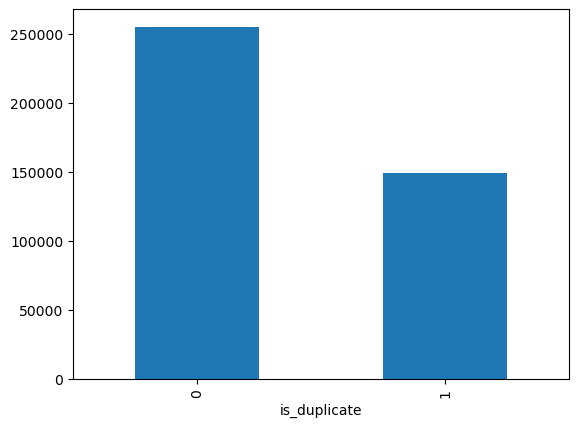

In [7]:
# Distribution of duplicate and non-duplicate questions

print(df['is_duplicate'].value_counts())
print((df['is_duplicate'].value_counts()/df['is_duplicate'].count())*100)
df['is_duplicate'].value_counts().plot(kind='bar')

In [8]:
# Repeated questions

qid = pd.Series(df['qid1'].tolist() + df['qid2'].tolist())
print('Number of unique questions',np.unique(qid).shape[0])
x = qid.value_counts()>1
print('Number of questions getting repeated',x[x].shape[0])

Number of unique questions 789801
Number of questions getting repeated 13698


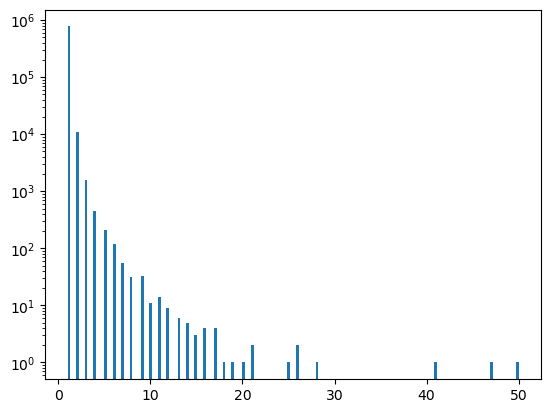

In [9]:
# Repeated questions histogram

plt.hist(qid.value_counts().values,bins=160)
plt.yscale('log')
plt.show()